Fitting 5 folds for each of 15 candidates, totalling 75 fits


C:\Users\mohda\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:31:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Test ROC–AUC: 0.8438
PR–AUC: 0.6645
Selected Threshold (Recall ≥ 0.85): 0.399

Confusion Matrix
[[684 351]
 [ 54 320]]

Classification Report
              precision    recall  f1-score   support

           0     0.9268    0.6609    0.7716      1035
           1     0.4769    0.8556    0.6124       374

    accuracy                         0.7126      1409
   macro avg     0.7019    0.7582    0.6920      1409
weighted avg     0.8074    0.7126    0.7293      1409



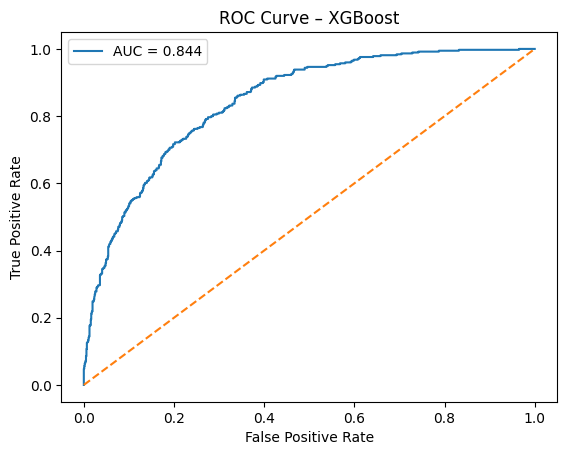


Top 10 Important Features:
Contract_Two year                 0.265413
InternetService_Fiber optic       0.153904
Contract_One year                 0.153788
InternetService_No                0.098112
PaymentMethod_Electronic check    0.054568
StreamingMovies_Yes               0.037750
tenure                            0.037392
OnlineSecurity_Yes                0.022367
StreamingTV_Yes                   0.020627
PaperlessBilling_Yes              0.018322
dtype: float32


In [1]:
# ============================================================
# CUSTOMER CHURN – XGBOOST (BUSINESS-ALIGNED VERSION)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)

from xgboost import XGBClassifier

# -------------------------
# 1. LOAD + CLEAN
# -------------------------
df = pd.read_csv("CustomerChurn.csv")

df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

# -------------------------
# 2. TARGET + FEATURES
# -------------------------
y = (df["Churn"] == "Yes").astype(int)
df = df.drop(columns=["Churn"])

cat_cols = df.select_dtypes(include="object").columns
X = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# -------------------------
# 3. TRAIN–TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# 4. HANDLE IMBALANCE
# -------------------------
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# -------------------------
# 5. HYPERPARAMETER SEARCH
# -------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False
)

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_xgb = search.best_estimator_

print("Best Parameters:", search.best_params_)

# -------------------------
# 6. ROC–AUC
# -------------------------
y_prob = best_xgb.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("Test ROC–AUC:", round(roc_auc, 4))

# -------------------------
# 7. PR–AUC
# -------------------------
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print("PR–AUC:", round(pr_auc, 4))

# -------------------------
# 8. BUSINESS THRESHOLD SELECTION
# Maintain Recall ≥ 0.85, maximize precision
# -------------------------
thresholds = np.linspace(0.1, 0.9, 100)

chosen_threshold = 0
best_precision = 0

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    rec = recall_score(y_test, preds)
    prec = precision_score(y_test, preds)

    if rec >= 0.85 and prec > best_precision:
        best_precision = prec
        chosen_threshold = t

print("Selected Threshold (Recall ≥ 0.85):", round(chosen_threshold, 3))

# -------------------------
# 9. FINAL METRICS
# -------------------------
y_pred = (y_prob >= chosen_threshold).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

# -------------------------
# 10. ROC CURVE
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()

# -------------------------
# 11. FEATURE IMPORTANCE
# -------------------------
importances = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importances.head(10))

C:\Users\mohda\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


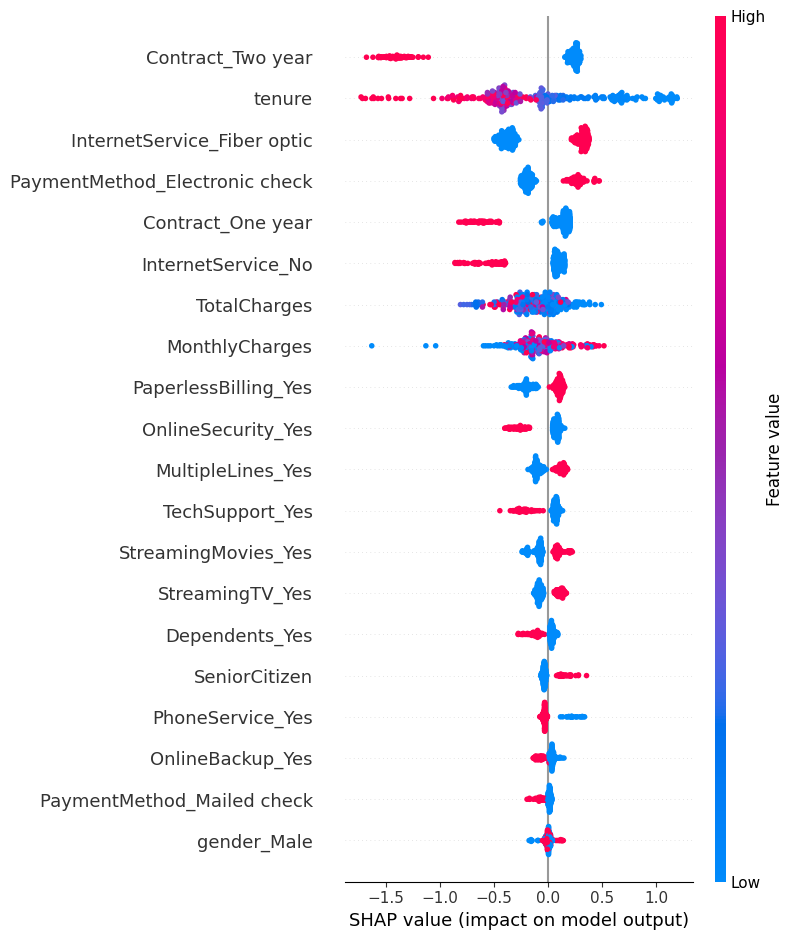

In [2]:
import shap

# -------------------------
# SHAP EXPLAINABILITY (TREE-BASED)
# -------------------------

# Create TreeExplainer
explainer = shap.TreeExplainer(best_xgb)

# Use smaller sample for speed
X_sample = X_test.iloc[:300]

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Global Summary Plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns
)